# Ewaluacja leksykalnego upraszczania tekstów modelem BERT



In [1]:
%pip install wordfreq==3.1.1 matplotlib nltk==3.9.4 numpy==2.4.4 pandas==3.0.3 seaborn==0.13.2 torch==2.12.0 tqdm==4.67.3 transformers==5.8.1 wordfreq==3.1.1


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Wczytywanie zbioru danych BenchLS

In [2]:
import os
import re
import urllib.request
import pandas as pd
import torch
from transformers import set_seed
from transformers.utils import logging
from transformers import AutoTokenizer, AutoModelForMaskedLM
from tqdm import tqdm

def load_benchls(url="https://raw.githubusercontent.com/qiang2100/BERT-LS/master/datasets/BenchLS.txt"):
    file_path = "benchls.txt"
    if not os.path.exists(file_path):
        urllib.request.urlretrieve(url, file_path)

    with open(file_path, 'r', encoding='utf-8') as f:
        total_lines = sum(1 for _ in f)

    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=total_lines, desc="LOAD"):
            parts = line.strip().split('\t')
            if len(parts) < 4:
                continue

            data.append({
                "sentence": parts[0],
                "target_word": parts[1],
                "gold_substitutes": [re.sub(r'^\d+:', '', c).strip().lower() for c in parts[3:] if c.strip()]
            })

    return pd.DataFrame(data)


logging.set_verbosity_error()
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

seed = 291
set_seed(seed)
torch.manual_seed(seed)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForMaskedLM.from_pretrained("bert-base-uncased")
model.eval()

df = load_benchls()
print(df.info())

c:\Users\Kuba\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import issparse


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

LOAD: 100%|██████████| 930/930 [00:00<00:00, 52839.30it/s]

<class 'pandas.DataFrame'>
RangeIndex: 929 entries, 0 to 928
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   sentence          929 non-null    str   
 1   target_word       929 non-null    str   
 2   gold_substitutes  929 non-null    object
dtypes: object(1), str(2)
memory usage: 21.9+ KB
None


## Wczytywanie kandydatów z wykorzystaniem modelu BERT

In [3]:
import os
import json
import re
import torch


def extract_candidates(row, model, tokenizer, max_k=50):
    sentence = row['sentence']
    target_word = row['target_word']

    masked_sentence = re.sub(
        rf'\b{re.escape(target_word)}\b',
        tokenizer.mask_token,
        sentence,
        count=1,
        flags=re.IGNORECASE
    )

    if tokenizer.mask_token not in masked_sentence:
        return []

    inputs = tokenizer(masked_sentence, return_tensors="pt")
    mask_idx = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1]

    if len(mask_idx) == 0:
        return []

    with torch.no_grad():
        logits = model(**inputs).logits

    mask_logits = logits[0, mask_idx[0], :]
    top_tokens = torch.topk(mask_logits, max_k * 2, dim=0).indices.tolist()

    candidates = []
    for token_id in top_tokens:
        word = tokenizer.decode([token_id]).strip().lower()
        if word.isalpha() and word != target_word.lower() and not word.startswith("##"):
            if word not in candidates:
                candidates.append(word)
        if len(candidates) == max_k:
            break

    return candidates

tqdm.pandas(desc="BERT")
df['candidates'] = df.progress_apply(lambda r: extract_candidates(r, model, tokenizer, 50), axis=1)

with open("bert_candidates.json", "w", encoding="utf-8") as f:
    json.dump(df['candidates'].tolist(), f, indent=4)

BERT: 100%|██████████| 929/929 [01:46<00:00,  8.72it/s]


## Eksperymenty

In [4]:
experimental_runs = []
k_space = [10, 30, 50]

def run_experiment(df, variant, k_val, predict_fn, **kwargs):
    results = []
    pbar = tqdm(
        df.iterrows(),
        total=len(df),
        desc=f"{variant.upper()} (K={k_val})",
        unit="row",
        dynamic_ncols=True,
        colour="cyan"
    )

    for n, (idx, row) in enumerate(pbar):
        ranked_preds = predict_fn(row, k=k_val, **kwargs)
        top1 = ranked_preds[0] if ranked_preds else row['target_word']
        gold = row['gold_substitutes']

        is_hit_top1 = top1 in gold
        is_hit_any = any(c in gold for c in ranked_preds[:5])

        if is_hit_top1:
            status = "Poprawna (Top-1)"
        elif is_hit_any:
            status = "Trafienie (Top-5)"
        elif ranked_preds == [row['target_word']]:
            status = "Brak kandydatów"
        else:
            status = "Brak trafienia"

        results.append({
            "index": idx,
            "target": row["target_word"],
            "gold": gold,
            "variant": variant.upper(),
            "k_val": k_val,
            "prediction": top1,
            "status": status,
            "hit": is_hit_top1,
            "ranked_candidates": ranked_preds
        })

        current_hits = sum(r['hit'] for r in results)
        pbar.set_postfix({
            "target": row["target_word"],
            "pred": top1,
            "hit": "✓" if is_hit_top1 else "✗",
            "P@1": f"{(current_hits / (n + 1)):.3f}"
        })

    pbar.close()

    exp_df = pd.DataFrame(results)
    exp_df['cumulative_p_at_1'] = exp_df['hit'].cumsum() / (exp_df.index + 1)

    final_p_at_1 = exp_df['hit'].sum() / len(exp_df) if len(exp_df) > 0 else 0.0
    print(f"[{variant.upper()}|K={k_val:<2}] Final P@1: {final_p_at_1:.4f}")

    exp_df.to_json(f"eval_{variant}_k{k_val}.json", orient="records", indent=4)
    return exp_df

def get_embedding(word, tokenizer, model):
    tokens = tokenizer(word, add_special_tokens=False, return_tensors="pt")["input_ids"]
    if tokens.shape[1] == 0:
        return None
    return model.get_input_embeddings()(tokens[0, 0].unsqueeze(0))

### Wariant 0

In [5]:
from wordfreq import word_frequency

def rank_v0(row, k, **kwargs):
    return row['candidates'][:k]

experimental_runs.append(run_experiment(df, 'v0', 10, rank_v0))

V0 (K=10): 100%|██████████| 929/929 [00:01<00:00, 491.01row/s, target=function, pred=functions, hit=✗, P@1=0.342]          


[V0|K=10] Final P@1: 0.3423


### Wariant 1 - ranking bezwarunkowy


In [6]:
from wordfreq import word_frequency

def rank_v1(row, k, **kwargs):
    target_word = row['target_word']
    candidates = row['candidates'][:k]

    if not candidates:
        return target_word

    return sorted(candidates, key=lambda w: word_frequency(w, 'en'), reverse=True)

for k in k_space:
    experimental_runs.append(run_experiment(df, 'v1', k, rank_v1))

V1 (K=10): 100%|██████████| 929/929 [00:02<00:00, 387.21row/s, target=function, pred=system, hit=✗, P@1=0.221]        


[V1|K=10] Final P@1: 0.2207


V1 (K=30): 100%|██████████| 929/929 [00:02<00:00, 405.10row/s, target=function, pred=system, hit=✗, P@1=0.150]        


[V1|K=30] Final P@1: 0.1496


V1 (K=50): 100%|██████████| 929/929 [00:02<00:00, 441.65row/s, target=function, pred=group, hit=✗, P@1=0.113]        


[V1|K=50] Final P@1: 0.1130


### Wariant 2 - projekcja geometryczna przestrzeni ukrytej

In [7]:
import torch.nn.functional as F
from wordfreq import zipf_frequency

def rank_v2(row, k, model, tokenizer, **kwargs):
    target_word = row['target_word']
    candidates = row['candidates'][:k]

    if not candidates:
        return target_word

    target_emb = get_embedding(target_word, tokenizer, model)
    if target_emb is None:
        return target_word

    scored = []
    for word in candidates:
        cand_emb = get_embedding(word, tokenizer, model)
        if cand_emb is not None:
            sim = F.cosine_similarity(target_emb, cand_emb).item()
            zipf = zipf_frequency(word, 'en')
            scored.append((word, sim * zipf))

    if not scored:
        return target_word

    scored.sort(key=lambda x: x[1], reverse=True)
    return [word for word, score in scored]

for k in k_space:
    experimental_runs.append(run_experiment(df, 'v2', k, rank_v2, model=model, tokenizer=tokenizer))

V2 (K=10): 100%|██████████| 929/929 [00:05<00:00, 162.16row/s, target=function, pred=functions, hit=✗, P@1=0.429]          


[V2|K=10] Final P@1: 0.4295


V2 (K=30): 100%|██████████| 929/929 [00:12<00:00, 76.00row/s, target=function, pred=functions, hit=✗, P@1=0.455]         


[V2|K=30] Final P@1: 0.4553


V2 (K=50): 100%|██████████| 929/929 [00:18<00:00, 49.89row/s, target=function, pred=functions, hit=✗, P@1=0.440]         


[V2|K=50] Final P@1: 0.4403


### Wariant 3 - morfologiczna normalizacja

In [8]:
import torch.nn.functional as F
from wordfreq import zipf_frequency
from nltk.stem import SnowballStemmer

def rank_v3(row, k, model, tokenizer, stemmer, **kwargs):
    target_word = row['target_word']
    candidates = row['candidates'][:k]

    if not candidates:
        return target_word

    target_stem = stemmer.stem(target_word.lower())
    target_emb = get_embedding(target_word, tokenizer, model)

    if target_emb is None:
        return target_word

    scored = []
    for word in candidates:
        if stemmer.stem(word) == target_stem:
            continue

        cand_emb = get_embedding(word, tokenizer, model)
        if cand_emb is not None:
            sim = F.cosine_similarity(target_emb, cand_emb).item()
            zipf = zipf_frequency(word, 'en')
            scored.append((word, sim * zipf))

    if not scored:
        return target_word

    scored.sort(key=lambda x: x[1], reverse=True)
    return [word for word, score in scored]

stemmer = SnowballStemmer("english")
for k in k_space:
    experimental_runs.append(run_experiment(df, 'v3', k, rank_v3, model=model, tokenizer=tokenizer, stemmer=stemmer))

V3 (K=10): 100%|██████████| 929/929 [00:06<00:00, 148.68row/s, target=function, pred=system, hit=✗, P@1=0.474]             


[V3|K=10] Final P@1: 0.4736


V3 (K=30): 100%|██████████| 929/929 [00:11<00:00, 77.61row/s, target=function, pred=system, hit=✗, P@1=0.530]            


[V3|K=30] Final P@1: 0.5296


V3 (K=50): 100%|██████████| 929/929 [00:16<00:00, 56.90row/s, target=function, pred=structure, hit=✗, P@1=0.533]         


[V3|K=50] Final P@1: 0.5328


## Podsumowanie wyników

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator, PercentFormatter, MultipleLocator

np.random.seed(291)
sns.set_theme(style="whitegrid")

df_long = pd.concat(experimental_runs, ignore_index=True)

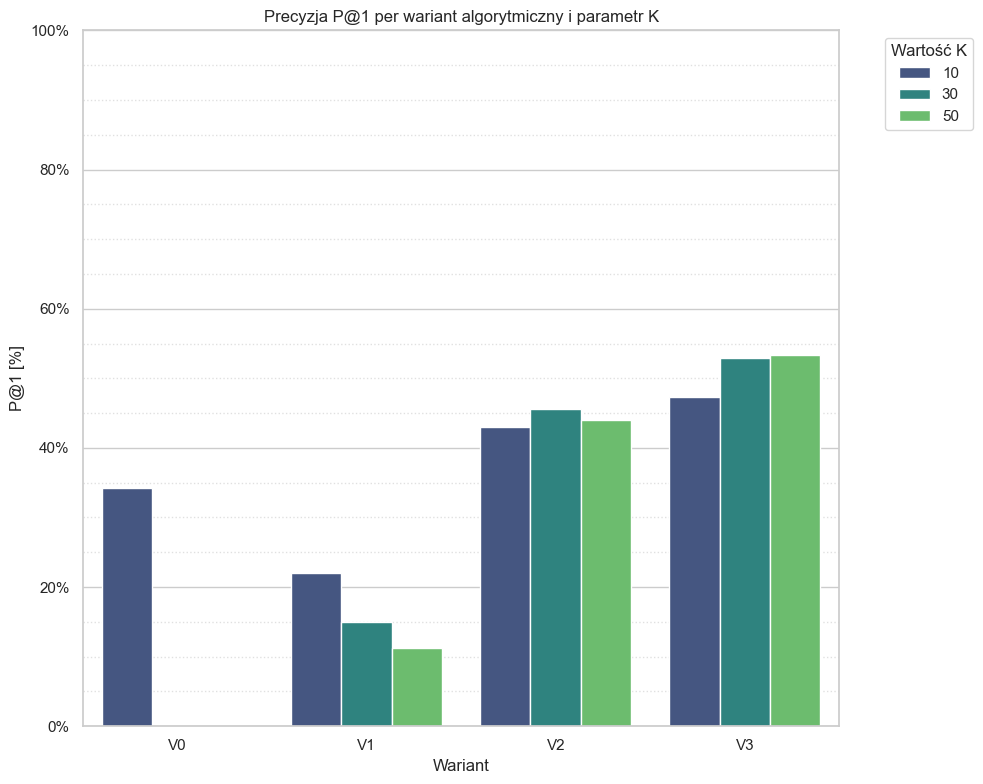

In [10]:
df_metrics = df_long.groupby(["variant", "k_val"]).agg(
    total=("hit", "count"),
    hits=("hit", "sum")
).reset_index()
df_metrics["k_val"] = df_metrics["k_val"].astype(str)
df_metrics["P@1"] = df_metrics["hits"] / df_metrics["total"]

fig1, ax1 = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_metrics, x="variant", y="P@1", hue="k_val", ax=ax1, palette="viridis")

ax1.set_title("Precyzja P@1 per wariant algorytmiczny i parametr K")
ax1.set_ylabel("P@1 [%]")
ax1.set_xlabel("Wariant")
ax1.set_ylim(0, 1.0)
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.grid(True, which='minor', axis='y', linestyle=':', alpha=0.6)
ax1.legend(title="Wartość K", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

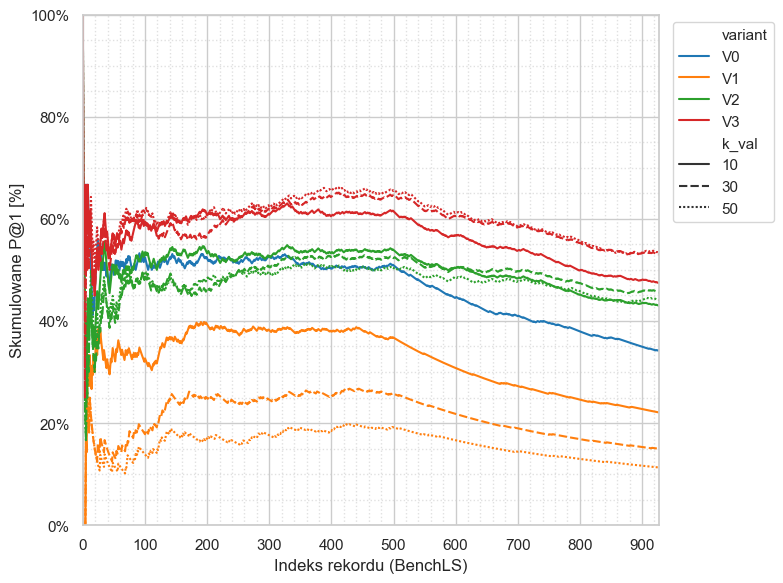

In [11]:
df_time = df_long.copy()
df_time.sort_values(by=["variant", "k_val", "index"], inplace=True)
df_time["cum_hits"] = df_time.groupby(["variant", "k_val"])["hit"].cumsum()
df_time["cum_total"] = df_time.groupby(["variant", "k_val"]).cumcount() + 1
df_time["cum_p1"] = df_time["cum_hits"] / df_time["cum_total"]

fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.lineplot(
    data=df_time, x="index", y="cum_p1",
    hue="variant", style="k_val",
    ax=ax2, palette="tab10", markers=False, dashes=True
)

# ax2.set_title("Przebieg indeksowy skumulowanej precyzji P@1")
ax2.set_xlabel("Indeks rekordu (BenchLS)")
ax2.set_ylabel("Skumulowane P@1 [%]")
ax2.set_xlim(0, df_long["index"].max())
ax2.set_ylim(0.0, 1.0)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.xaxis.set_major_locator(MultipleLocator(100))
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.grid(True, which='minor', linestyle=':', alpha=0.6)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

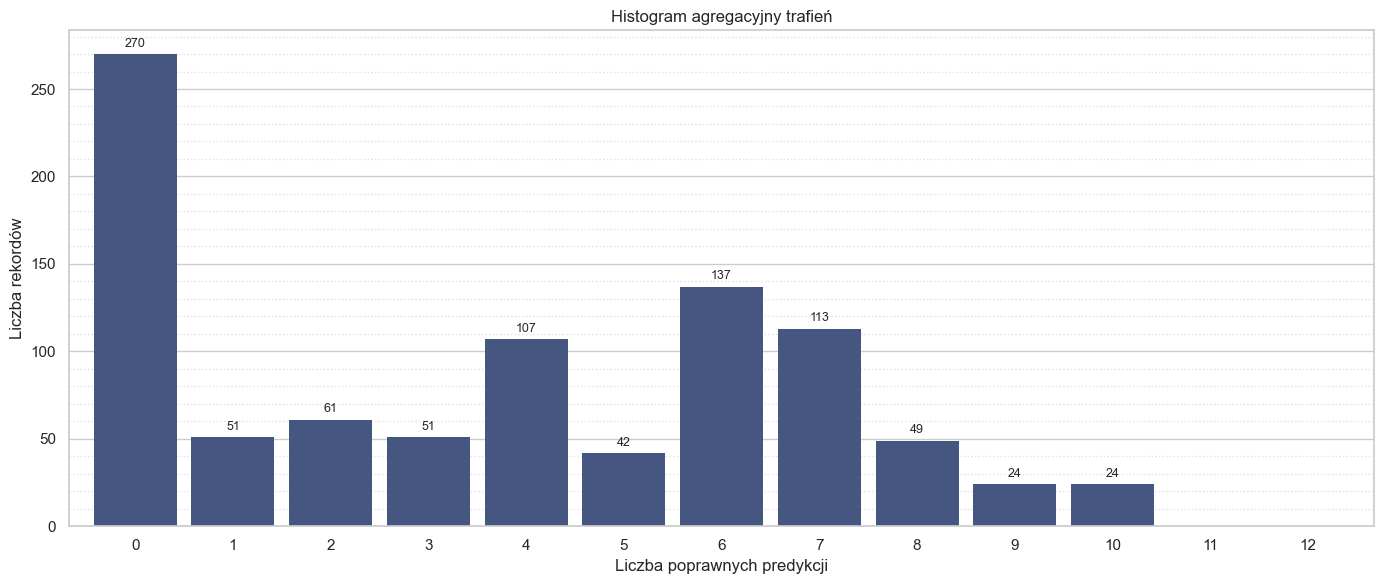

In [12]:
hits_per_record = df_long.groupby("index")["hit"].sum()
max_possible_hits = len(df_long['variant'].unique()) * len(df_long['k_val'].unique())
hit_counts = hits_per_record.value_counts().reindex(np.arange(max_possible_hits, -1, -1)).fillna(0)

fig3, ax3 = plt.subplots(figsize=(14, 6))
hit_counts.plot(kind="bar", ax=ax3, color="#455681", width=0.85, edgecolor="none")

ax3.set_title("Histogram agregacyjny trafień")
ax3.invert_xaxis()
ax3.set_xlabel(f"Liczba poprawnych predykcji")
ax3.set_ylabel("Liczba rekordów")
plt.setp(ax3.get_xticklabels(), rotation=0)
ax3.grid(False, axis='x')
ax3.yaxis.set_minor_locator(AutoMinorLocator())
ax3.grid(True, which='minor', axis='y', linestyle=':', alpha=0.6)

for p in ax3.patches:
    height = p.get_height()
    if height > 0:
        ax3.annotate(f"{int(height)}",
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

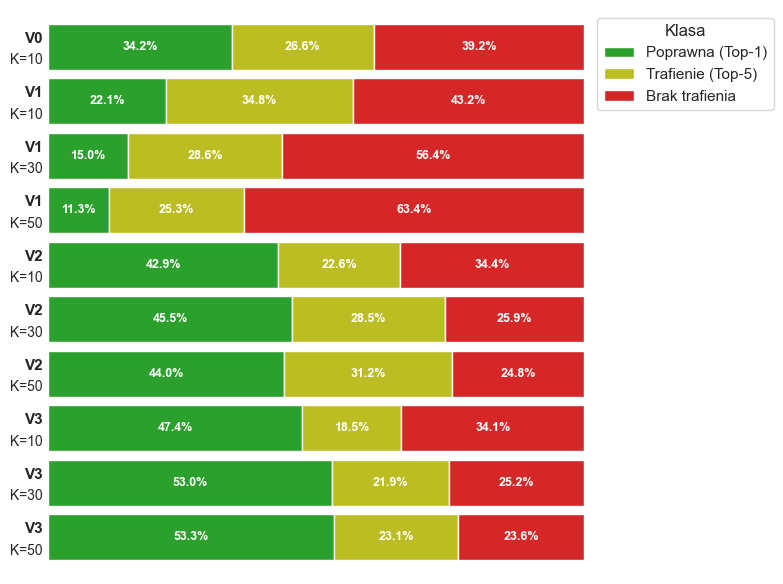

In [13]:
df_status = df_long.groupby(["variant", "k_val", "status"]).size().reset_index(name="count")
df_pivot = df_status.pivot(index=["variant", "k_val"], columns="status", values="count").fillna(0)

status_order = ["Poprawna (Top-1)", "Trafienie (Top-5)", "Brak trafienia", "Brak kandydatów"]
plot_cols = [c for c in status_order if c in df_pivot.columns]
df_pivot = df_pivot[plot_cols]
df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

variant_cat = pd.CategoricalDtype(categories=reversed(['V0', 'V1', 'V2', 'V3']), ordered=True)
k_cat = pd.CategoricalDtype(categories=reversed([10, 30, 50]), ordered=True)

df_pct.index = pd.MultiIndex.from_arrays([
    pd.Series(df_pct.index.get_level_values(0), dtype=variant_cat),
    pd.Series(df_pct.index.get_level_values(1), dtype=k_cat)
])
df_pct = df_pct.sort_index()

color_map = {
    "Poprawna (Top-1)": "#2ca02c",
    "Trafienie (Top-5)": "#bcbd22",
    "Brak trafienia": "#d62728",
    "Brak kandydatów": "#7f7f7f"
}
colors = [color_map.get(c, "#000000") for c in df_pct.columns]

fig4, ax4 = plt.subplots(figsize=(8, max(4, len(df_pct) * 0.6)))
df_pct.plot(kind="barh", stacked=True, ax=ax4, color=colors, width=0.85)
#ax4.set_title("Struktura odpowiedzi i dystrybucja błędów")
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_xlim((0, 100))
ax4.legend(title="Klasa", bbox_to_anchor=(1.01, 1), loc='upper left')
ax4.grid(False)
for spine in ax4.spines.values():
    spine.set_visible(False)

y_tick_positions = np.arange(len(df_pct))
ax4.set_yticks(y_tick_positions)
ax4.set_yticklabels([""] * len(df_pct))
ax4.set_xticks([])

for pos, (variant, k_val) in zip(y_tick_positions, df_pct.index):
    ax4.text(-1, pos + 0.15, variant, ha='right', va='center', weight='bold', fontsize=11)
    ax4.text(-1, pos - 0.25, f"K={k_val}", ha='right', va='center', fontsize=10)

for c in ax4.containers:
    for p in c:
        width = p.get_width()
        if width > 3.5:
            text = f"{width:.1f}%"
            if width < 6.0:
                text = f"{width:.0f}%"
            ax4.annotate(text,
                         (p.get_x() + width / 2., p.get_y() + p.get_height() / 2.),
                         ha='center', va='center', fontsize=9, color='white', weight='bold')

plt.subplots_adjust(left=0.2)
plt.tight_layout()
plt.show()

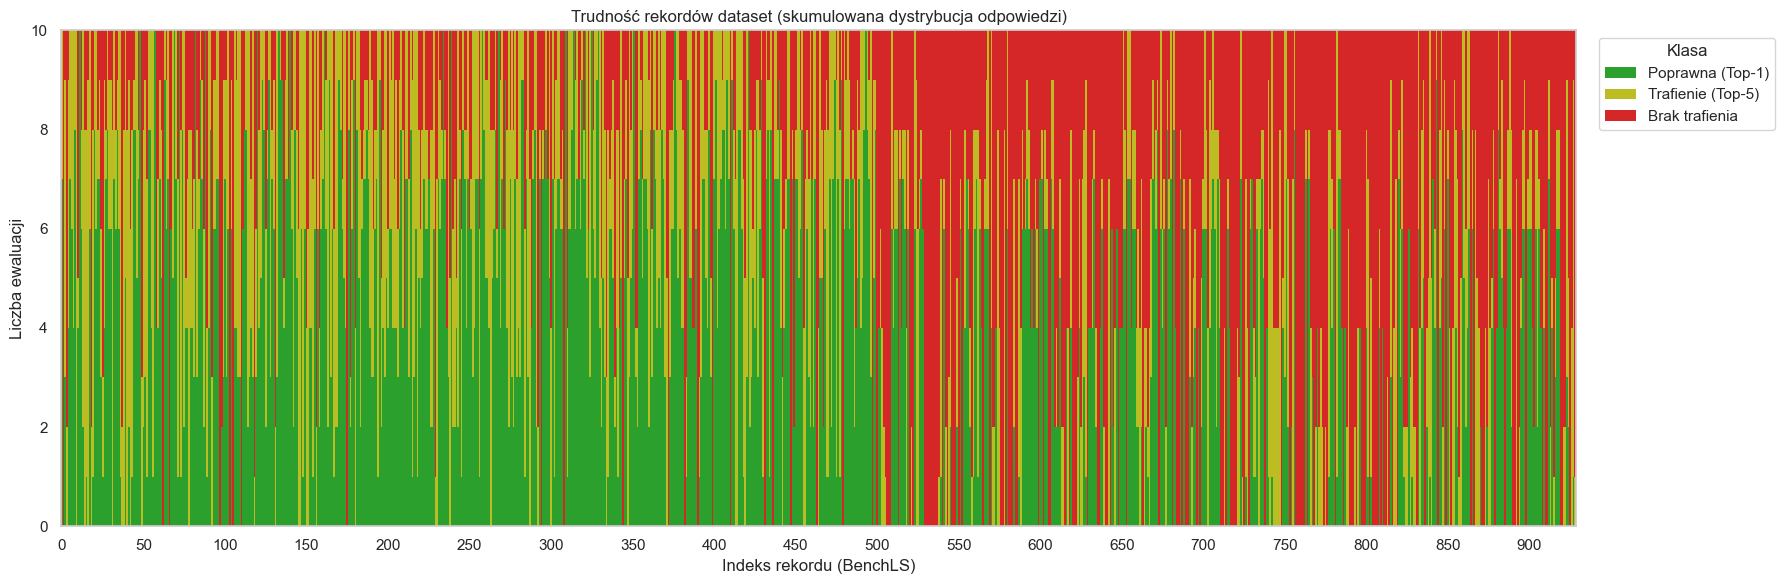

In [14]:
df_diff = df_long.groupby(["index", "status"]).size().reset_index(name="count")
df_diff_pivot = df_diff.pivot(index="index", columns="status", values="count").fillna(0)

status_order = ["Poprawna (Top-1)", "Trafienie (Top-5)", "Brak trafienia", "Brak kandydatów"]
plot_cols = [c for c in status_order if c in df_diff_pivot.columns]
df_diff_pivot = df_diff_pivot[plot_cols]

color_map = {
    "Poprawna (Top-1)": "#2ca02c",
    "Trafienie (Top-5)": "#bcbd22",
    "Brak trafienia": "#d62728",
    "Brak kandydatów": "#7f7f7f"
}
colors_diff = [color_map.get(c, "#000000") for c in df_diff_pivot.columns]

fig5, ax5 = plt.subplots(figsize=(18, 6))
df_diff_pivot.plot(kind="bar", stacked=True, ax=ax5, color=colors_diff, width=1.0, edgecolor='none')
ax5.set_title("Trudność rekordów dataset (skumulowana dystrybucja odpowiedzi)")
ax5.set_xlabel("Indeks rekordu (BenchLS)")
ax5.set_ylabel("Liczba ewaluacji")
ax5.set_ylim(0, df_diff_pivot.sum(axis=1).max())
ax5.legend(title="Klasa", bbox_to_anchor=(1.01, 1), loc='upper left')

ticks = ax5.xaxis.get_ticklocs()
ax5.xaxis.set_ticks(ticks[::50])
ax5.xaxis.set_ticklabels(df_diff_pivot.index[::50], rotation=0)

plt.tight_layout()
plt.show()